# 03 - Hyperbolic Decline DCA

In this notebook, we extend the analytical decline curve analysis from exponential decline to hyperbolic decline.

The hyperbolic decline equation is:

q(t) = qi / (1 + b * Di * t)^(1 / b)

Where:

- q(t) is production at time t
- qi is the initial fitted production rate
- Di is the initial decline rate
- b is the hyperbolic decline exponent

This notebook will start with the median type curve and then move toward per-well hyperbolic fits.

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [3]:
DATA_FILE = Path(
    r"C:\Users\tawac\Documents\SEM UT at Dallas Program"
    r"\SEM_JD_Market_Research_2026-06-17"
    r"\portfolio\permian_type_curve"
    r"\data\processed\martin_selected_30_monthly_production_normalized.csv"
)

OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

In [4]:
df = pd.read_csv(
    DATA_FILE,
    dtype={
        "api8": str,
        "lease_no": str,
        "district": str,
    },
)

df.head()

,api8,district,lease_no,well_no,lease_name,operator_name,field_name,first_prod_month,cycle_year_month,month_on_production,oil_bbl,casinghead_gas_mcf,boe,interval_length_proxy_ft,reported_first_month,first_positive_prod_month,reported_month_on_production
0,31743171,10,56651,4H,BOHANAN-BLOCKER 3B,"PIONEER NATURAL RES. USA, INC.",SPRABERRY (TREND AREA),202201,202201,1,27270.0,26374.0,31665.666667,10036.0,202201,202201,1
1,31743171,10,56651,4H,BOHANAN-BLOCKER 3B,"PIONEER NATURAL RES. USA, INC.",SPRABERRY (TREND AREA),202201,202202,2,25100.0,24522.0,29187.000000,10036.0,202201,202201,2
2,31743171,10,56651,4H,BOHANAN-BLOCKER 3B,"PIONEER NATURAL RES. USA, INC.",SPRABERRY (TREND AREA),202201,202203,3,22589.0,23927.0,26576.833333,10036.0,202201,202201,3
3,31743171,10,56651,4H,BOHANAN-BLOCKER 3B,"PIONEER NATURAL RES. USA, INC.",SPRABERRY (TREND AREA),202201,202204,4,18960.0,20036.0,22299.333333,10036.0,202201,202201,4
4,31743171,10,56651,4H,BOHANAN-BLOCKER 3B,"PIONEER NATURAL RES. USA, INC.",SPRABERRY (TREND AREA),202201,202205,5,18050.0,17744.0,21007.333333,10036.0,202201,202201,5


In [5]:
numeric_columns = [
    "month_on_production",
    "oil_bbl",
    "casinghead_gas_mcf",
    "boe",
    "interval_length_proxy_ft",
]

for column in numeric_columns:
    df[column] = pd.to_numeric(df[column], errors="coerce")

df = df.sort_values(["api8", "month_on_production"]).reset_index(drop=True)

df.head()

,api8,district,lease_no,well_no,lease_name,operator_name,field_name,first_prod_month,cycle_year_month,month_on_production,oil_bbl,casinghead_gas_mcf,boe,interval_length_proxy_ft,reported_first_month,first_positive_prod_month,reported_month_on_production
0,31743171,10,56651,4H,BOHANAN-BLOCKER 3B,"PIONEER NATURAL RES. USA, INC.",SPRABERRY (TREND AREA),202201,202201,1,27270.0,26374.0,31665.666667,10036.0,202201,202201,1
1,31743171,10,56651,4H,BOHANAN-BLOCKER 3B,"PIONEER NATURAL RES. USA, INC.",SPRABERRY (TREND AREA),202201,202202,2,25100.0,24522.0,29187.000000,10036.0,202201,202201,2
2,31743171,10,56651,4H,BOHANAN-BLOCKER 3B,"PIONEER NATURAL RES. USA, INC.",SPRABERRY (TREND AREA),202201,202203,3,22589.0,23927.0,26576.833333,10036.0,202201,202201,3
3,31743171,10,56651,4H,BOHANAN-BLOCKER 3B,"PIONEER NATURAL RES. USA, INC.",SPRABERRY (TREND AREA),202201,202204,4,18960.0,20036.0,22299.333333,10036.0,202201,202201,4
4,31743171,10,56651,4H,BOHANAN-BLOCKER 3B,"PIONEER NATURAL RES. USA, INC.",SPRABERRY (TREND AREA),202201,202205,5,18050.0,17744.0,21007.333333,10036.0,202201,202201,5


In [6]:
median_curve = (
    df[df["month_on_production"].between(1, 33)]
    .groupby("month_on_production", as_index=False)
    .agg(median_oil_bbl=("oil_bbl", "median"))
)

median_curve.head()

,month_on_production,median_oil_bbl
0,1,12627.5
1,2,29502.5
2,3,22872.5
3,4,18845.5
4,5,17784.5


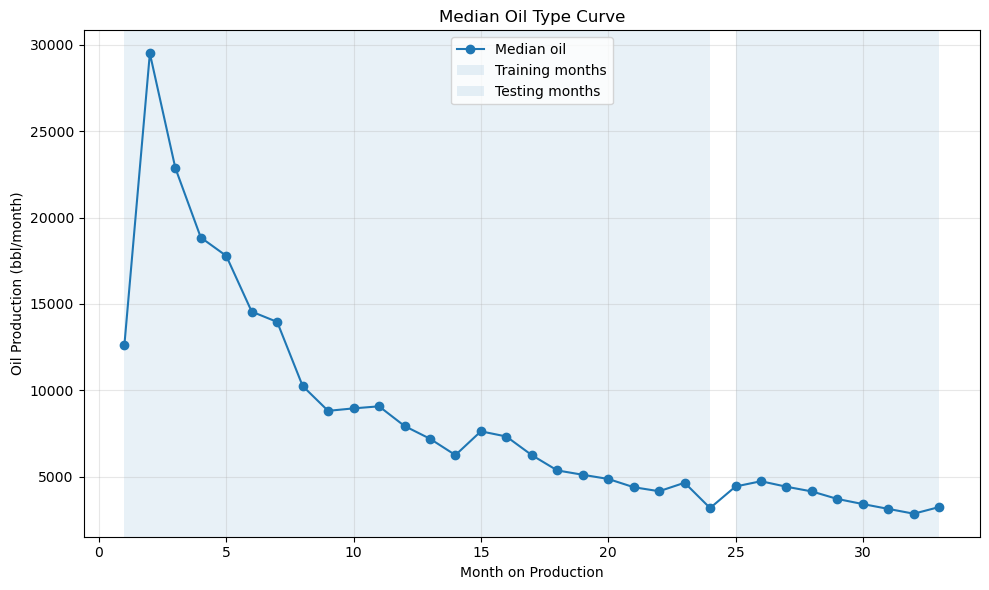

In [7]:
plt.figure(figsize=(10, 6))

plt.plot(
    median_curve["month_on_production"],
    median_curve["median_oil_bbl"],
    marker="o",
    label="Median oil",
)

plt.axvspan(1, 24, alpha=0.10, label="Training months")
plt.axvspan(25, 33, alpha=0.10, label="Testing months")

plt.title("Median Oil Type Curve")
plt.xlabel("Month on Production")
plt.ylabel("Oil Production (bbl/month)")
plt.legend()
plt.grid(True, alpha=0.30)
plt.tight_layout()
plt.show()

In [8]:
def predict_hyperbolic(months, qi, di, b):
    months = np.asarray(months, dtype=float)

    return qi / ((1 + b * di * months) ** (1 / b))

In [9]:
def hyperbolic_sse_for_b_di(fit_data, b, di, month_column="month_on_production", rate_column="median_oil_bbl"):
    adjusted_log_rates = (
        np.log(fit_data[rate_column])
        + (1 / b) * np.log(1 + b * di * fit_data[month_column])
    )

    log_qi = adjusted_log_rates.mean()
    qi = np.exp(log_qi)

    fitted_rates = predict_hyperbolic(
        fit_data[month_column],
        qi,
        di,
        b,
    )

    sse = np.sum(
        (np.log(fit_data[rate_column]) - np.log(fitted_rates)) ** 2
    )

    return sse, qi

In [10]:
def fit_hyperbolic_decline(
    curve,
    month_column,
    rate_column,
    start_month=2,
    end_month=24,
):
    fit_data = curve[curve[month_column].between(start_month, end_month)].copy()
    fit_data = fit_data[fit_data[rate_column] > 0].copy()

    best_sse = np.inf
    best_qi = None
    best_di = None
    best_b = None

    b_grid = np.linspace(0.05, 1.50, 50)
    di_grid = np.linspace(0.001, 0.400, 100)

    for b in b_grid:
        for di in di_grid:
            sse, qi = hyperbolic_sse_for_b_di(
                fit_data,
                b,
                di,
                month_column=month_column,
                rate_column=rate_column,
            )

            if sse < best_sse:
                best_sse = sse
                best_qi = qi
                best_di = di
                best_b = b

    return best_qi, best_di, best_b, fit_data, best_sse

In [11]:
median_hyp_qi, median_hyp_di, median_hyp_b, median_hyp_fit_data, median_hyp_sse = fit_hyperbolic_decline(
    median_curve,
    month_column="month_on_production",
    rate_column="median_oil_bbl",
    start_month=2,
    end_month=24,
)

print(f"Fitted qi: {median_hyp_qi:,.0f} bbl/month")
print(f"Fitted Di: {median_hyp_di:.4f} per month")
print(f"Fitted b-factor: {median_hyp_b:.3f}")

Fitted qi: 52,435 bbl/month
Fitted Di: 0.3879 per month
Fitted b-factor: 0.849


In [12]:
plot_months = np.arange(1, 34)

median_curve["hyperbolic_fit_oil_bbl"] = predict_hyperbolic(
    plot_months,
    median_hyp_qi,
    median_hyp_di,
    median_hyp_b,
)

median_curve.head()

,month_on_production,median_oil_bbl,hyperbolic_fit_oil_bbl
0,1,12627.5,37496.756964
1,2,29502.5,28891.545875
2,3,22872.5,23341.168703
3,4,18845.5,19485.386544
4,5,17784.5,16662.224069


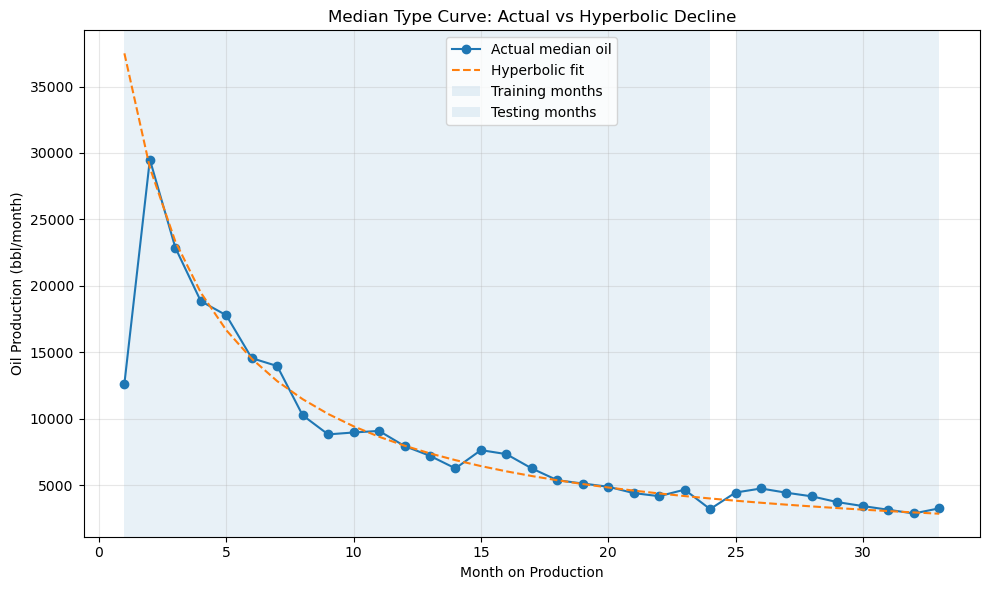

In [13]:
plt.figure(figsize=(10, 6))

plt.plot(
    median_curve["month_on_production"],
    median_curve["median_oil_bbl"],
    marker="o",
    label="Actual median oil",
)

plt.plot(
    median_curve["month_on_production"],
    median_curve["hyperbolic_fit_oil_bbl"],
    linestyle="--",
    label="Hyperbolic fit",
)

plt.axvspan(1, 24, alpha=0.10, label="Training months")
plt.axvspan(25, 33, alpha=0.10, label="Testing months")

plt.title("Median Type Curve: Actual vs Hyperbolic Decline")
plt.xlabel("Month on Production")
plt.ylabel("Oil Production (bbl/month)")
plt.legend()
plt.grid(True, alpha=0.30)
plt.tight_layout()
plt.show()

In [14]:
def calculate_error_metrics(curve, prediction_column):
    metric_rows = []

    for window_name, start_month, end_month in [
        ("train", 2, 24),
        ("test", 25, 33),
    ]:
        window_data = curve[
            curve["month_on_production"].between(start_month, end_month)
        ].copy()

        actual = window_data["median_oil_bbl"]
        predicted = window_data[prediction_column]

        error = predicted - actual

        mae = error.abs().mean()
        rmse = np.sqrt((error ** 2).mean())
        bias = error.mean()

        smape = (
            np.abs(predicted - actual)
            / ((np.abs(actual) + np.abs(predicted)) / 2)
        ).mean() * 100

        metric_rows.append(
            {
                "model": "hyperbolic_decline",
                "window": window_name,
                "start_month": start_month,
                "end_month": end_month,
                "observations": len(window_data),
                "mae_bbl": mae,
                "rmse_bbl": rmse,
                "bias_bbl": bias,
                "smape_percent": smape,
            }
        )

    return pd.DataFrame(metric_rows)

In [15]:
hyperbolic_metrics = calculate_error_metrics(
    median_curve,
    prediction_column="hyperbolic_fit_oil_bbl",
)

hyperbolic_metrics

,model,window,start_month,end_month,observations,mae_bbl,rmse_bbl,bias_bbl,smape_percent
0,hyperbolic_decline,train,2,24,23,580.480364,741.042712,-28.182542,7.067301
1,hyperbolic_decline,test,25,33,9,515.677533,611.221072,-498.402604,13.690890


In [16]:
median_curve.to_csv(
    OUTPUT_DIR / "median_hyperbolic_decline_curve.csv",
    index=False,
)

hyperbolic_metrics.to_csv(
    OUTPUT_DIR / "hyperbolic_decline_metrics.csv",
    index=False,
)


In [17]:
hyperbolic_fit_summary = pd.DataFrame(
    [
        {
            "curve_name": "median_type_curve",
            "fit_start_month": 2,
            "fit_end_month": 24,
            "qi_bbl_per_month": median_hyp_qi,
            "di_per_month": median_hyp_di,
            "di_percent_per_month": median_hyp_di * 100,
            "b_factor": median_hyp_b,
            "log_space_sse": median_hyp_sse,
        }
    ]
)

hyperbolic_fit_summary

,curve_name,fit_start_month,fit_end_month,qi_bbl_per_month,di_per_month,di_percent_per_month,b_factor,log_space_sse
0,median_type_curve,2,24,52434.568166,0.387909,38.790909,0.84898,0.209238


In [18]:
hyperbolic_fit_summary.to_csv(
    OUTPUT_DIR / "hyperbolic_decline_fit_summary.csv",
    index=False,
)

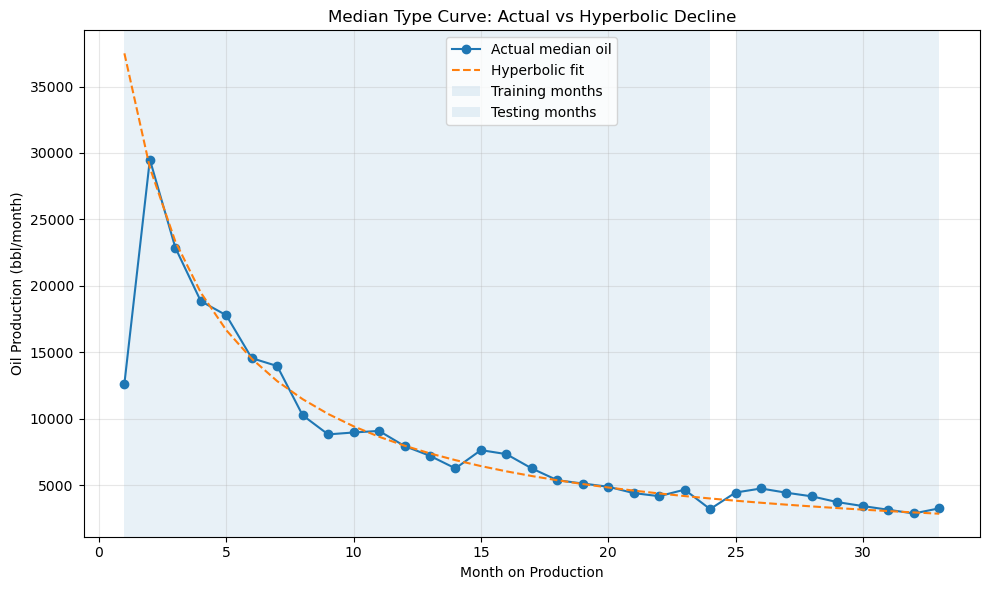

In [19]:
plt.figure(figsize=(10, 6))

plt.plot(
    median_curve["month_on_production"],
    median_curve["median_oil_bbl"],
    marker="o",
    label="Actual median oil",
)

plt.plot(
    median_curve["month_on_production"],
    median_curve["hyperbolic_fit_oil_bbl"],
    linestyle="--",
    label="Hyperbolic fit",
)

plt.axvspan(1, 24, alpha=0.10, label="Training months")
plt.axvspan(25, 33, alpha=0.10, label="Testing months")

plt.title("Median Type Curve: Actual vs Hyperbolic Decline")
plt.xlabel("Month on Production")
plt.ylabel("Oil Production (bbl/month)")
plt.legend()
plt.grid(True, alpha=0.30)
plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "median_hyperbolic_decline_fit.png",
    dpi=150,
)

plt.show()

## Median Hyperbolic DCA Checkpoint

We fit a hyperbolic decline model to the median oil type curve.

Fit setup:

- Curve: median monthly oil production
- Fit window: months 2-24
- Test window: months 25-33
- Month 1 was not used for fitting because it may represent partial first-month production.

Model form:

q(t) = qi / (1 + b * Di * t)^(1 / b)

Interpretation:

The fitted hyperbolic model estimates three parameters:

- `qi`: fitted initial oil production rate
- `Di`: fitted initial monthly decline rate
- `b`: decline-shape factor

Compared with exponential decline, hyperbolic decline is more flexible because the decline rate changes over time instead of staying constant.

Early observation:

The median hyperbolic curve should be compared against the earlier exponential curve using the same train/test windows before making a final judgment.

In [21]:
def fit_exponential_decline(
    curve,
    month_column,
    rate_column,
    start_month=2,
    end_month=24,
):
    fit_data = curve[curve[month_column].between(start_month, end_month)].copy()
    fit_data = fit_data[fit_data[rate_column] > 0].copy()

    x = fit_data[month_column].to_numpy(dtype=float)
    y = fit_data[rate_column].to_numpy(dtype=float)

    slope, intercept = np.polyfit(x, np.log(y), 1)

    qi = float(np.exp(intercept))
    di = float(-slope)

    return qi, di, fit_data


def predict_exponential(months, qi, di):
    months = np.asarray(months, dtype=float)

    return qi * np.exp(-di * months)

In [22]:
median_exp_qi, median_exp_di, median_exp_fit_data = fit_exponential_decline(
    median_curve,
    month_column="month_on_production",
    rate_column="median_oil_bbl",
    start_month=2,
    end_month=24,
)

median_curve["exponential_fit_oil_bbl"] = predict_exponential(
    plot_months,
    median_exp_qi,
    median_exp_di,
)

print(f"Exponential qi: {median_exp_qi:,.0f} bbl/month")
print(f"Exponential Di: {median_exp_di:.4f} per month")
print(f"Exponential Di: {median_exp_di * 100:.2f}% per month")

Exponential qi: 24,736 bbl/month
Exponential Di: 0.0836 per month
Exponential Di: 8.36% per month


In [23]:
exponential_metrics = calculate_error_metrics(
    median_curve,
    prediction_column="exponential_fit_oil_bbl",
)

exponential_metrics["model"] = "exponential_decline"

exponential_metrics

,model,window,start_month,end_month,observations,mae_bbl,rmse_bbl,bias_bbl,smape_percent
0,exponential_decline,train,2,24,23,1329.688574,2236.068956,-272.767909,11.508489
1,exponential_decline,test,25,33,9,1554.854246,1574.814937,-1554.854246,52.306473


In [24]:
dca_metric_comparison = pd.concat(
    [
        exponential_metrics,
        hyperbolic_metrics,
    ],
    ignore_index=True,
)

dca_metric_comparison

,model,window,start_month,end_month,observations,mae_bbl,rmse_bbl,bias_bbl,smape_percent
0,exponential_decline,train,2,24,23,1329.688574,2236.068956,-272.767909,11.508489
1,exponential_decline,test,25,33,9,1554.854246,1574.814937,-1554.854246,52.306473
2,hyperbolic_decline,train,2,24,23,580.480364,741.042712,-28.182542,7.067301
3,hyperbolic_decline,test,25,33,9,515.677533,611.221072,-498.402604,13.690890


In [25]:
dca_metric_comparison.to_csv(
    OUTPUT_DIR / "dca_metric_comparison_exponential_vs_hyperbolic.csv",
    index=False,
)

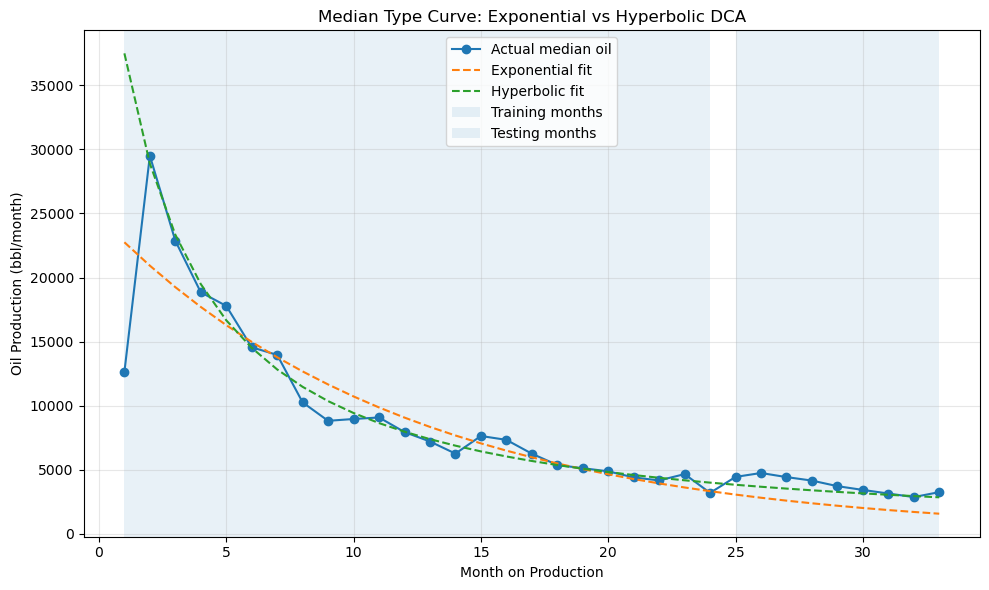

In [26]:
plt.figure(figsize=(10, 6))

plt.plot(
    median_curve["month_on_production"],
    median_curve["median_oil_bbl"],
    marker="o",
    label="Actual median oil",
)

plt.plot(
    median_curve["month_on_production"],
    median_curve["exponential_fit_oil_bbl"],
    linestyle="--",
    label="Exponential fit",
)

plt.plot(
    median_curve["month_on_production"],
    median_curve["hyperbolic_fit_oil_bbl"],
    linestyle="--",
    label="Hyperbolic fit",
)

plt.axvspan(1, 24, alpha=0.10, label="Training months")
plt.axvspan(25, 33, alpha=0.10, label="Testing months")

plt.title("Median Type Curve: Exponential vs Hyperbolic DCA")
plt.xlabel("Month on Production")
plt.ylabel("Oil Production (bbl/month)")
plt.legend()
plt.grid(True, alpha=0.30)
plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "median_exponential_vs_hyperbolic_dca.png",
    dpi=150,
)

plt.show()

## Per-Well Hyperbolic DCA

The median type curve gives one cohort-level view, but each well may decline differently.

In this section, we fit a separate hyperbolic decline model to each well.

Setup:

- Fit window: months 12-24
- Forecast-check window: months 25-33
- Target: monthly oil production
- Model: hyperbolic decline

We use months 12-24 for fitting because the early production period can be noisy, and the later fit window better reflects stabilized decline behavior.

The goal is not to make a reserves estimate. The goal is to compare forecast behavior across wells and prepare fair DCA baselines for later ML comparison.

In [28]:
PER_WELL_FIT_START_MONTH = 12
PER_WELL_FIT_END_MONTH = 24

FORECAST_START_MONTH = 25
FORECAST_END_MONTH = 33

In [29]:
per_well_hyp_results = []
per_well_hyp_forecasts = []
skipped_hyp_wells = []

for api8, well_data in df.groupby("api8"):
    well_curve = well_data[
        well_data["month_on_production"].between(1, FORECAST_END_MONTH)
    ].copy()

    fit_window_data = well_curve[
        well_curve["month_on_production"].between(
            PER_WELL_FIT_START_MONTH,
            PER_WELL_FIT_END_MONTH,
        )
    ].copy()

    forecast_data = well_curve[
        well_curve["month_on_production"].between(
            FORECAST_START_MONTH,
            FORECAST_END_MONTH,
        )
    ].copy()

    if len(fit_window_data) < 6:
        skipped_hyp_wells.append(
            {
                "api8": api8,
                "reason": "fewer_than_6_fit_months",
                "fit_rows": len(fit_window_data),
                "forecast_rows": len(forecast_data),
            }
        )
        continue

    if len(forecast_data) == 0:
        skipped_hyp_wells.append(
            {
                "api8": api8,
                "reason": "no_forecast_months",
                "fit_rows": len(fit_window_data),
                "forecast_rows": len(forecast_data),
            }
        )
        continue

    if (fit_window_data["oil_bbl"] > 0).sum() < 6:
        skipped_hyp_wells.append(
            {
                "api8": api8,
                "reason": "fewer_than_6_positive_fit_months",
                "fit_rows": len(fit_window_data),
                "forecast_rows": len(forecast_data),
            }
        )
        continue

    try:
        qi, di, b, fit_data, sse = fit_hyperbolic_decline(
            well_curve,
            month_column="month_on_production",
            rate_column="oil_bbl",
            start_month=PER_WELL_FIT_START_MONTH,
            end_month=PER_WELL_FIT_END_MONTH,
        )
    except Exception as error:
        skipped_hyp_wells.append(
            {
                "api8": api8,
                "reason": f"fit_error: {error}",
                "fit_rows": len(fit_window_data),
                "forecast_rows": len(forecast_data),
            }
        )
        continue

    forecast_data["hyperbolic_forecast_oil_bbl"] = predict_hyperbolic(
        forecast_data["month_on_production"],
        qi,
        di,
        b,
    )

    actual_test_oil_bbl = forecast_data["oil_bbl"].sum()
    forecast_test_oil_bbl = forecast_data["hyperbolic_forecast_oil_bbl"].sum()

    if actual_test_oil_bbl == 0:
        skipped_hyp_wells.append(
            {
                "api8": api8,
                "reason": "zero_actual_test_oil",
                "fit_rows": len(fit_window_data),
                "forecast_rows": len(forecast_data),
            }
        )
        continue

    error_bbl = forecast_test_oil_bbl - actual_test_oil_bbl
    percent_error = error_bbl / actual_test_oil_bbl * 100

    per_well_hyp_results.append(
        {
            "api8": api8,
            "lease_name": well_curve["lease_name"].iloc[0],
            "well_no": well_curve["well_no"].iloc[0],
            "fit_start_month": PER_WELL_FIT_START_MONTH,
            "fit_end_month": PER_WELL_FIT_END_MONTH,
            "forecast_start_month": FORECAST_START_MONTH,
            "forecast_end_month": FORECAST_END_MONTH,
            "qi_bbl_per_month": qi,
            "di_per_month": di,
            "di_percent_per_month": di * 100,
            "b_factor": b,
            "log_space_sse": sse,
            "actual_test_oil_bbl": actual_test_oil_bbl,
            "forecast_test_oil_bbl": forecast_test_oil_bbl,
            "error_bbl": error_bbl,
            "percent_error": percent_error,
        }
    )

    per_well_hyp_forecasts.append(forecast_data)

In [30]:
len(per_well_hyp_results), len(skipped_hyp_wells)

(30, 0)

In [31]:
pd.DataFrame(skipped_hyp_wells).head()

""


In [32]:
per_well_hyp_results_df = pd.DataFrame(per_well_hyp_results)

per_well_hyp_results_df = (
    per_well_hyp_results_df
    .sort_values("percent_error")
    .reset_index(drop=True)
)

per_well_hyp_results_df["absolute_percent_error"] = (
    per_well_hyp_results_df["percent_error"].abs()
)

per_well_hyp_results_df

,api8,lease_name,well_no,fit_start_month,fit_end_month,forecast_start_month,forecast_end_month,qi_bbl_per_month,di_per_month,di_percent_per_month,b_factor,log_space_sse,actual_test_oil_bbl,forecast_test_oil_bbl,error_bbl,percent_error,absolute_percent_error
0,31744055,DAVIS-LACY 31K,211H,12,24,25,33,57064.449818,0.158182,15.818182,0.138776,0.898896,49251.0,15287.788776,-33963.211224,-68.959435,68.959435
1,31744070,DAVIS-LACY 31C,203H,12,24,25,33,23618.308362,0.121909,12.190909,0.050000,0.595059,22233.0,8509.396770,-13723.603230,-61.726277,61.726277
2,31743757,GLYNN-ATCHISON 44M,213H,12,24,25,33,13762.116993,0.400000,40.000000,1.500000,2.475786,35704.0,17841.876108,-17862.123892,-50.028355,50.028355
3,31743755,GLYNN-ATCHISON 44N,214H,12,24,25,33,96328.904806,0.234758,23.475758,0.316327,1.189524,46559.0,23537.879533,-23021.120467,-49.445049,49.445049
4,31744067,DAVIS-LACY 31F,206H,12,24,25,33,96107.088622,0.210576,21.057576,0.227551,0.528354,38239.0,19420.193084,-18818.806916,-49.213648,49.213648
5,31744058,DAVIS-LACY 31H,208H,12,24,25,33,36730.590238,0.134000,13.400000,0.050000,0.359109,16956.0,9908.705203,-7047.294797,-41.562248,41.562248
6,31743171,BOHANAN-BLOCKER 3B,4H,12,24,25,33,35669.867980,0.097727,9.772727,0.050000,0.222771,36835.0,23257.641480,-13577.358520,-36.859939,36.859939
7,31744066,EPLEY-MARTIN 31K,111H,12,24,25,33,43408.643602,0.101758,10.175758,0.050000,0.366116,38148.0,25603.704355,-12544.295645,-32.883233,32.883233
8,31744057,DAVIS-LACY 31I,209H,12,24,25,33,68834.781684,0.400000,40.000000,0.848980,1.179312,55854.0,37686.963839,-18167.036161,-32.525936,32.525936
9,31744053,EPLEY-MARTIN 31D,104H,12,24,25,33,16851.033473,0.065485,6.548485,0.050000,1.001059,36143.0,25025.700865,-11117.299135,-30.759204,30.759204


In [33]:
per_well_hyp_forecast_df = pd.concat(
    per_well_hyp_forecasts,
    ignore_index=True,
)

per_well_hyp_forecast_df.head()

,api8,district,lease_no,well_no,lease_name,operator_name,field_name,first_prod_month,cycle_year_month,month_on_production,oil_bbl,casinghead_gas_mcf,boe,interval_length_proxy_ft,reported_first_month,first_positive_prod_month,reported_month_on_production,hyperbolic_forecast_oil_bbl
0,31743171,10,56651,4H,BOHANAN-BLOCKER 3B,"PIONEER NATURAL RES. USA, INC.",SPRABERRY (TREND AREA),202201,202401,25,2639.0,15643.0,5246.166667,10036.0,202201,202201,25,3558.056654
1,31743171,10,56651,4H,BOHANAN-BLOCKER 3B,"PIONEER NATURAL RES. USA, INC.",SPRABERRY (TREND AREA),202201,202402,26,2580.0,17013.0,5415.500000,10036.0,202201,202201,26,3261.916697
2,31743171,10,56651,4H,BOHANAN-BLOCKER 3B,"PIONEER NATURAL RES. USA, INC.",SPRABERRY (TREND AREA),202201,202403,27,3901.0,4562.0,4661.333333,10036.0,202201,202201,27,2991.549153
3,31743171,10,56651,4H,BOHANAN-BLOCKER 3B,"PIONEER NATURAL RES. USA, INC.",SPRABERRY (TREND AREA),202201,202404,28,4403.0,4124.0,5090.333333,10036.0,202201,202201,28,2744.614060
4,31743171,10,56651,4H,BOHANAN-BLOCKER 3B,"PIONEER NATURAL RES. USA, INC.",SPRABERRY (TREND AREA),202201,202405,29,4712.0,5720.0,5665.333333,10036.0,202201,202201,29,2518.992647


In [79]:
per_well_hyp_error_summary = pd.DataFrame(
    [
        {
            "model": "hyperbolic_decline",
            "wells_fit": len(per_well_hyp_results_df),
            "mean_absolute_percent_error": per_well_hyp_results_df["absolute_percent_error"].mean(),
            "median_absolute_percent_error": per_well_hyp_results_df["absolute_percent_error"].median(),
            "mean_percent_error": per_well_hyp_results_df["percent_error"].mean(),
            "median_percent_error": per_well_hyp_results_df["percent_error"].median(),
            "mean_b_factor": per_well_hyp_results_df["b_factor"].mean(),
            "median_b_factor": per_well_hyp_results_df["b_factor"].median(),
            "min_b_factor": per_well_hyp_results_df["b_factor"].min(),
            "max_b_factor": per_well_hyp_results_df["b_factor"].max(),
        }
    ]
)

per_well_hyp_error_summary

,model,wells_fit,mean_absolute_percent_error,median_absolute_percent_error,mean_percent_error,median_percent_error,mean_b_factor,median_b_factor,min_b_factor,max_b_factor
0,hyperbolic_decline,30,35.038683,27.694182,-6.608255,-20.716348,0.440612,0.079592,0.05,1.5


In [80]:
per_well_hyp_results_df.to_csv(
    OUTPUT_DIR / "per_well_hyperbolic_dca_results.csv",
    index=False,
)

per_well_hyp_error_summary.to_csv(
    OUTPUT_DIR / "per_well_hyperbolic_dca_error_summary.csv",
    index=False,
)

per_well_hyp_forecast_df.to_csv(
    OUTPUT_DIR / "per_well_hyperbolic_dca_monthly_forecasts.csv",
    index=False,
)

In [81]:
best_hyp_fit_api8s = (
    per_well_hyp_results_df
    .sort_values("absolute_percent_error")
    .head(3)["api8"]
    .tolist()
)

worst_hyp_fit_api8s = (
    per_well_hyp_results_df
    .sort_values("absolute_percent_error", ascending=False)
    .head(3)["api8"]
    .tolist()
)

best_hyp_fit_api8s, worst_hyp_fit_api8s

(['31744072', '31744051', '31743816'], ['31744069', '31743568', '31744055'])

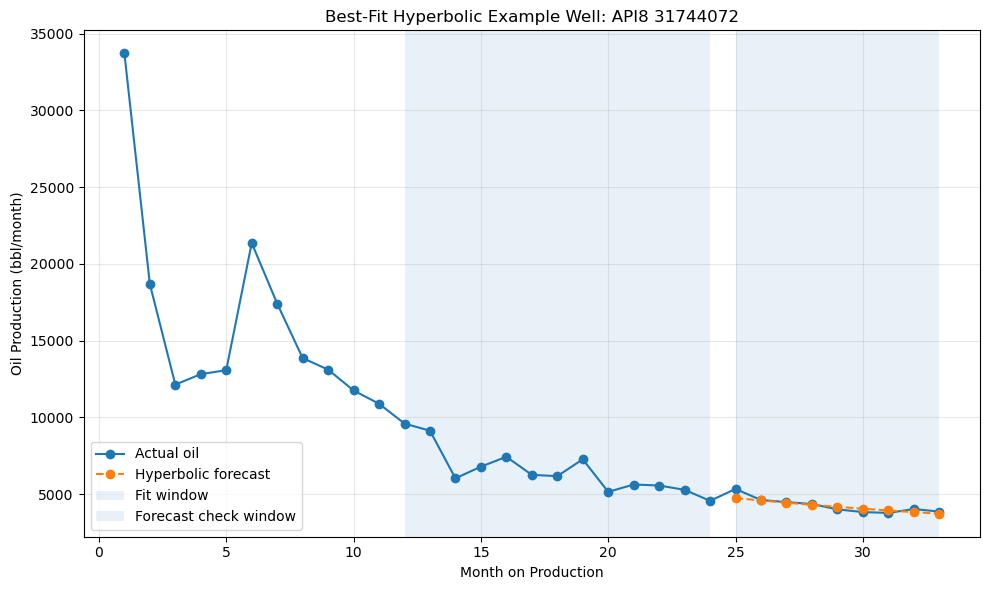

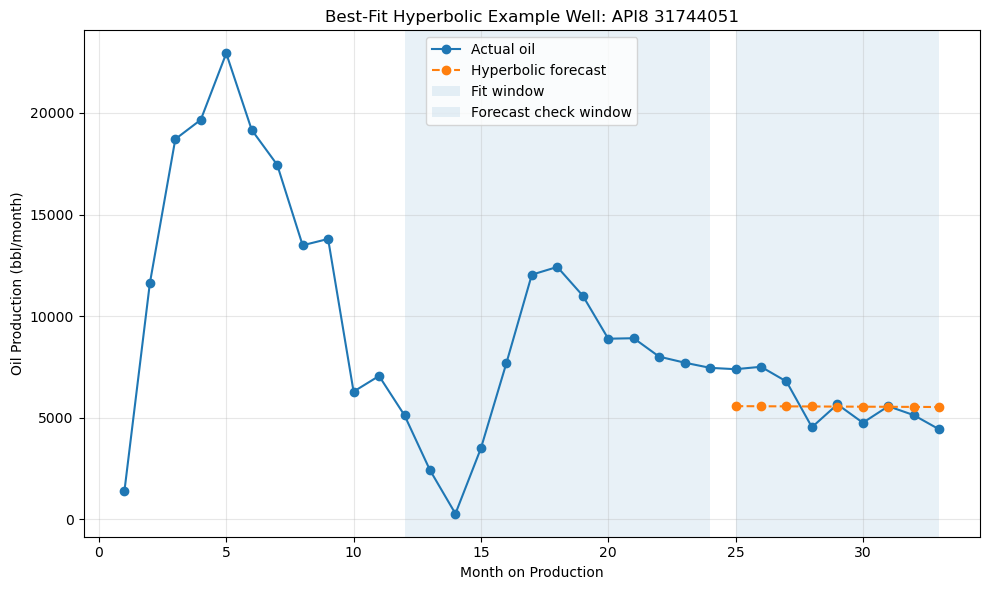

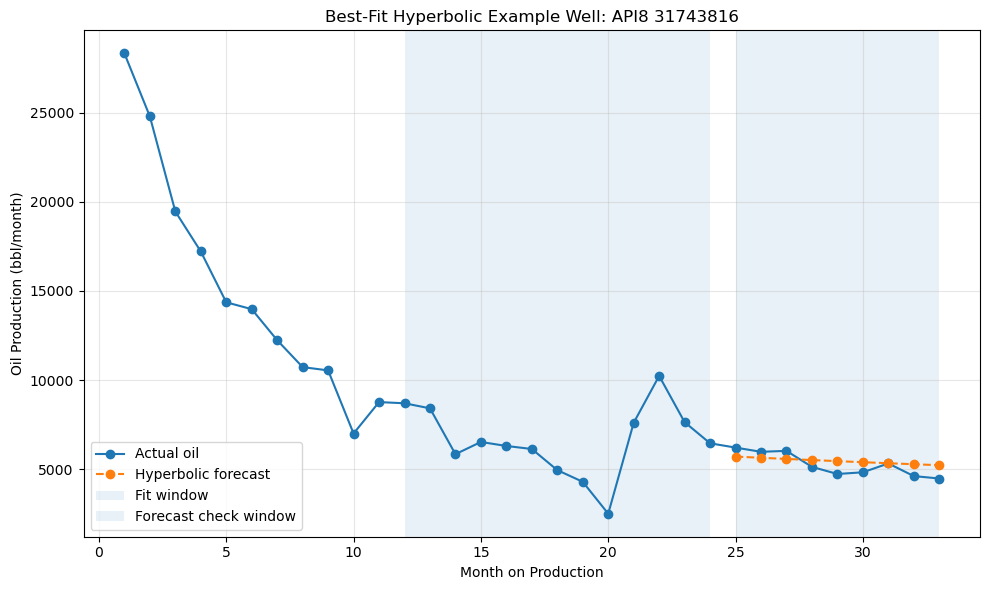

In [82]:
for api8 in best_hyp_fit_api8s:
    well_history = df[
        (df["api8"] == api8)
        & (df["month_on_production"].between(1, 33))
    ].copy()

    well_forecast = per_well_hyp_forecast_df[
        per_well_hyp_forecast_df["api8"] == api8
    ].copy()

    plt.figure(figsize=(10, 6))

    plt.plot(
        well_history["month_on_production"],
        well_history["oil_bbl"],
        marker="o",
        label="Actual oil",
    )

    plt.plot(
        well_forecast["month_on_production"],
        well_forecast["hyperbolic_forecast_oil_bbl"],
        marker="o",
        linestyle="--",
        label="Hyperbolic forecast",
    )

    plt.axvspan(12, 24, alpha=0.10, label="Fit window")
    plt.axvspan(25, 33, alpha=0.10, label="Forecast check window")

    plt.title(f"Best-Fit Hyperbolic Example Well: API8 {api8}")
    plt.xlabel("Month on Production")
    plt.ylabel("Oil Production (bbl/month)")
    plt.legend()
    plt.grid(True, alpha=0.30)
    plt.tight_layout()
    plt.show()
    

In [83]:
example_hyp_well_groups = pd.DataFrame(
    {
        "best_fit_api8": pd.Series(best_hyp_fit_api8s),
        "worst_fit_api8": pd.Series(worst_hyp_fit_api8s),
    }
)

example_hyp_well_groups

,best_fit_api8,worst_fit_api8
0,31744072,31744069
1,31744051,31743568
2,31743816,31744055


In [84]:
example_hyp_well_groups.to_csv(
    OUTPUT_DIR / "example_best_and_worst_hyperbolic_dca_wells.csv",
    index=False,
)

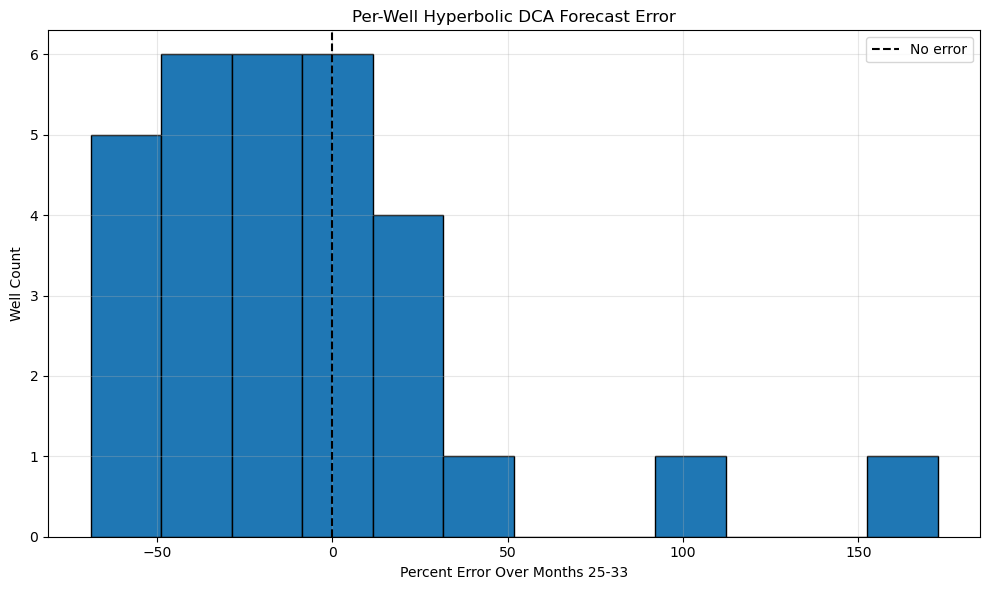

In [85]:
plt.figure(figsize=(10, 6))

plt.hist(
    per_well_hyp_results_df["percent_error"],
    bins=12,
    edgecolor="black",
)

plt.axvline(
    0,
    color="black",
    linestyle="--",
    label="No error",
)

plt.title("Per-Well Hyperbolic DCA Forecast Error")
plt.xlabel("Percent Error Over Months 25-33")
plt.ylabel("Well Count")
plt.legend()
plt.grid(True, alpha=0.30)
plt.tight_layout()
plt.show()

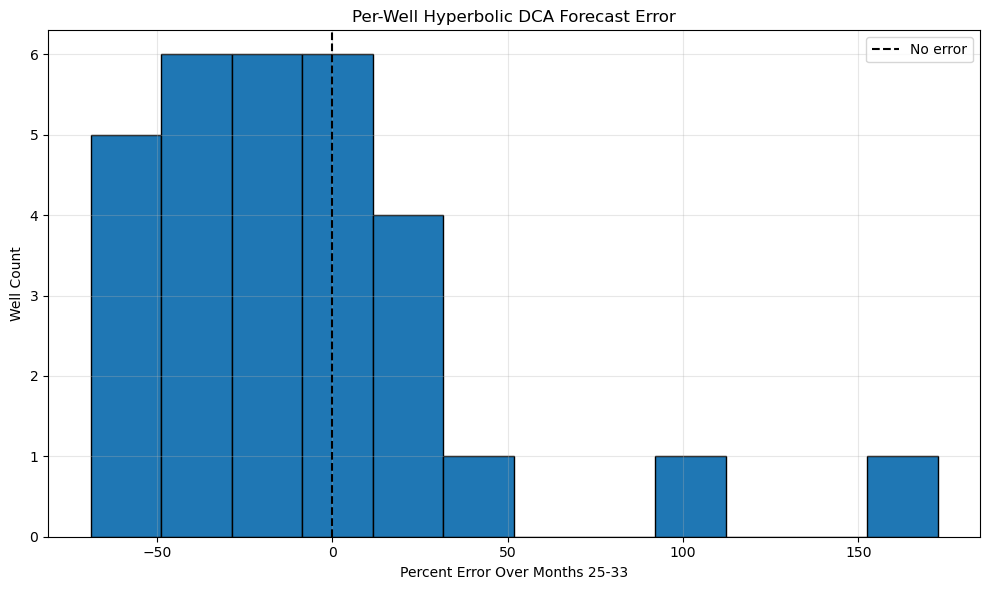

In [91]:
plt.figure(figsize=(10, 6))

plt.hist(
    per_well_hyp_results_df["percent_error"],
    bins=12,
    edgecolor="black",
)

plt.axvline(
    0,
    color="black",
    linestyle="--",
    label="No error",
)

plt.title("Per-Well Hyperbolic DCA Forecast Error")
plt.xlabel("Percent Error Over Months 25-33")
plt.ylabel("Well Count")
plt.legend()
plt.grid(True, alpha=0.30)
plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "per_well_hyperbolic_dca_forecast_error.png",
    dpi=150,
)

plt.show()

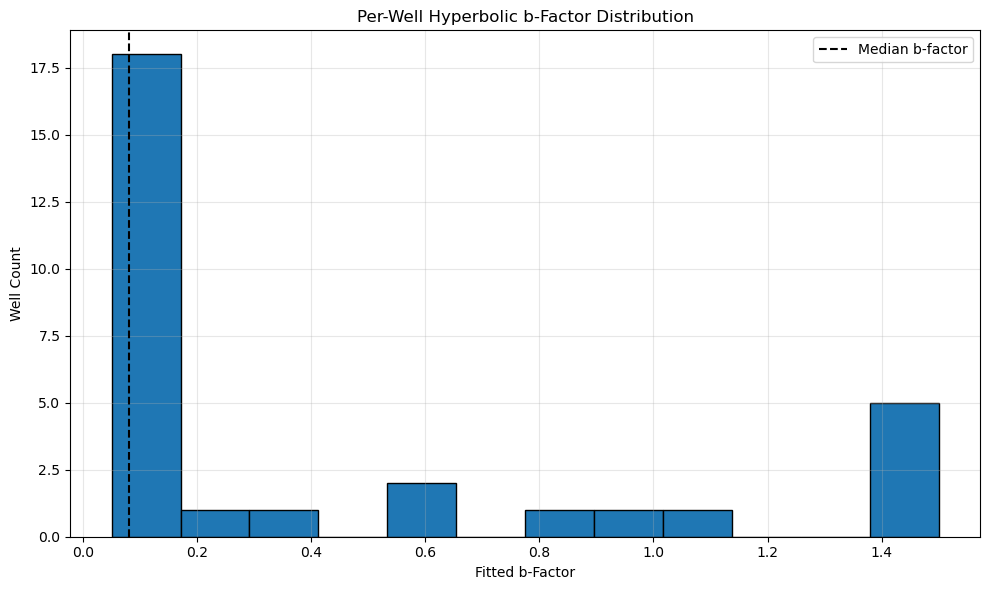

In [92]:
plt.figure(figsize=(10, 6))

plt.hist(
    per_well_hyp_results_df["b_factor"],
    bins=12,
    edgecolor="black",
)

plt.axvline(
    per_well_hyp_results_df["b_factor"].median(),
    color="black",
    linestyle="--",
    label="Median b-factor",
)

plt.title("Per-Well Hyperbolic b-Factor Distribution")
plt.xlabel("Fitted b-Factor")
plt.ylabel("Well Count")
plt.legend()
plt.grid(True, alpha=0.30)
plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "per_well_hyperbolic_b_factor_distribution.png",
    dpi=150,
)

plt.show()

## Per-Well Hyperbolic DCA Checkpoint

We completed the first per-well hyperbolic decline workflow.

Method:

- Each well was fit separately using monthly oil production.
- The fitting window was months 12-24.
- The forecast-check window was months 25-33.
- Forecast error was calculated by comparing forecasted oil to actual oil over months 25-33.
- The fitted `b` factor was saved for each well.

Outputs created:

- `per_well_hyperbolic_dca_results.csv`
- `per_well_hyperbolic_dca_error_summary.csv`
- `per_well_hyperbolic_dca_monthly_forecasts.csv`
- `example_best_and_worst_hyperbolic_dca_wells.csv`
- `per_well_hyperbolic_dca_forecast_error.png`
- `per_well_hyperbolic_b_factor_distribution.png`

Interpretation:

The hyperbolic model provides a more flexible DCA form than exponential decline because it estimates a decline-shape parameter, `b`, for each well.

In this first per-well run, all 30 wells fit successfully. The error distribution still shows meaningful variation across wells, which suggests that individual production behavior is not fully captured by a smooth decline curve alone.

The fitted `b`-factor distribution is especially useful. Wells with very low `b` values behave closer to exponential decline, while wells with higher `b` values may show more gradual decline behavior or noisier fit dynamics.

Project decision:

Hyperbolic DCA is now ready to compare against exponential DCA and later machine learning baselines at the per-well level.

In [74]:
per_well_hyp_comparison_ready = per_well_hyp_results_df[
    [
        "api8",
        "lease_name",
        "well_no",
        "actual_test_oil_bbl",
        "forecast_test_oil_bbl",
        "error_bbl",
        "percent_error",
        "absolute_percent_error",
        "qi_bbl_per_month",
        "di_per_month",
        "di_percent_per_month",
        "b_factor",
    ]
].copy()

per_well_hyp_comparison_ready = per_well_hyp_comparison_ready.rename(
    columns={
        "forecast_test_oil_bbl": "hyperbolic_forecast_test_oil_bbl",
        "error_bbl": "hyperbolic_error_bbl",
        "percent_error": "hyperbolic_percent_error",
        "absolute_percent_error": "hyperbolic_absolute_percent_error",
        "qi_bbl_per_month": "hyperbolic_qi_bbl_per_month",
        "di_per_month": "hyperbolic_di_per_month",
        "di_percent_per_month": "hyperbolic_di_percent_per_month",
        "b_factor": "hyperbolic_b_factor",
    }
)

per_well_hyp_comparison_ready

,api8,lease_name,well_no,actual_test_oil_bbl,hyperbolic_forecast_test_oil_bbl,hyperbolic_error_bbl,hyperbolic_percent_error,hyperbolic_absolute_percent_error,hyperbolic_qi_bbl_per_month,hyperbolic_di_per_month,hyperbolic_di_percent_per_month,hyperbolic_b_factor
0,31744055,DAVIS-LACY 31K,211H,49251.0,15287.788776,-33963.211224,-68.959435,68.959435,57064.449818,0.158182,15.818182,0.138776
1,31744070,DAVIS-LACY 31C,203H,22233.0,8509.396770,-13723.603230,-61.726277,61.726277,23618.308362,0.121909,12.190909,0.050000
2,31743757,GLYNN-ATCHISON 44M,213H,35704.0,17841.876108,-17862.123892,-50.028355,50.028355,13762.116993,0.400000,40.000000,1.500000
3,31743755,GLYNN-ATCHISON 44N,214H,46559.0,23537.879533,-23021.120467,-49.445049,49.445049,96328.904806,0.234758,23.475758,0.316327
4,31744067,DAVIS-LACY 31F,206H,38239.0,19420.193084,-18818.806916,-49.213648,49.213648,96107.088622,0.210576,21.057576,0.227551
5,31744058,DAVIS-LACY 31H,208H,16956.0,9908.705203,-7047.294797,-41.562248,41.562248,36730.590238,0.134000,13.400000,0.050000
6,31743171,BOHANAN-BLOCKER 3B,4H,36835.0,23257.641480,-13577.358520,-36.859939,36.859939,35669.867980,0.097727,9.772727,0.050000
7,31744066,EPLEY-MARTIN 31K,111H,38148.0,25603.704355,-12544.295645,-32.883233,32.883233,43408.643602,0.101758,10.175758,0.050000
8,31744057,DAVIS-LACY 31I,209H,55854.0,37686.963839,-18167.036161,-32.525936,32.525936,68834.781684,0.400000,40.000000,0.848980
9,31744053,EPLEY-MARTIN 31D,104H,36143.0,25025.700865,-11117.299135,-30.759204,30.759204,16851.033473,0.065485,6.548485,0.050000


In [75]:
per_well_hyp_comparison_ready.to_csv(
    OUTPUT_DIR / "per_well_hyperbolic_comparison_ready.csv",
    index=False,
)

## Hyperbolic DCA Notebook Closing Notes

This notebook completed the first hyperbolic decline analysis for the Martin County 30-well cohort.

Completed work:

- Rebuilt the median oil type curve.
- Fit hyperbolic decline to the median type curve.
- Compared median hyperbolic DCA against median exponential DCA.
- Fit hyperbolic decline separately for all 30 wells.
- Forecasted months 25-33 for each well.
- Summarized forecast error across wells.
- Saved comparison-ready outputs for later model comparison.

Key observations:

- Hyperbolic decline adds flexibility through the fitted `b` factor.
- The median type curve comparison helps show whether a changing decline rate improves over constant exponential decline.
- At the per-well level, fitted `b` factors varied across wells.
- Many wells may still behave close to exponential decline if their fitted `b` is low.
- Some wells may be hard to forecast with any smooth DCA curve because of production noise, rebounds, or operational changes.

Files saved:

- `median_hyperbolic_decline_curve.csv`
- `hyperbolic_decline_metrics.csv`
- `hyperbolic_decline_fit_summary.csv`
- `median_hyperbolic_decline_fit.png`
- `dca_metric_comparison_exponential_vs_hyperbolic.csv`
- `median_exponential_vs_hyperbolic_dca.png`
- `per_well_hyperbolic_dca_results.csv`
- `per_well_hyperbolic_dca_error_summary.csv`
- `per_well_hyperbolic_dca_monthly_forecasts.csv`
- `example_best_and_worst_hyperbolic_dca_wells.csv`
- `per_well_hyperbolic_dca_forecast_error.png`
- `per_well_hyperbolic_b_factor_distribution.png`
- `per_well_hyperbolic_comparison_ready.csv`

Next project step:

Use the saved exponential and hyperbolic per-well outputs to build a side-by-side DCA model comparison, then move toward simple machine learning baselines.


# DCA Model Comparison: Exponential vs Hyperbolic

In this section, we compare the per-well exponential and hyperbolic DCA results.

The goal is to answer:

- Which DCA model has lower forecast error over months 25-33?
- Which model has less forecast bias?
- How often does hyperbolic decline improve over exponential decline?
- Are the improvements large enough to justify the added `b`-factor complexity?

Both models use the same forecast-check window:

- Forecast-check months: 25-33
- Target: total oil production over the forecast-check window
- Comparison level: individual wells

In [105]:
per_well_exp_results_df = pd.read_csv(
    OUTPUT_DIR / "per_well_exponential_dca_results.csv",
    dtype={"api8": str},
)

per_well_exp_results_df.head()


,api8,lease_name,well_no,fit_start_month,fit_end_month,forecast_start_month,forecast_end_month,qi_bbl_per_month,di_per_month,di_percent_per_month,actual_test_oil_bbl,forecast_test_oil_bbl,error_bbl,percent_error,absolute_percent_error
0,31744055,DAVIS-LACY 31K,211H,12,24,25,33,41030.023976,0.114282,11.428191,49251.0,14020.293239,-35230.706761,-71.532978,71.532978
1,31744070,DAVIS-LACY 31C,203H,12,24,25,33,21892.731349,0.111224,11.122382,22233.0,8156.221462,-14076.778538,-63.314796,63.314796
2,31743755,GLYNN-ATCHISON 44N,214H,12,24,25,33,41702.860315,0.101292,10.129168,46559.0,20579.572042,-25979.427958,-55.798939,55.798939
3,31744067,DAVIS-LACY 31F,206H,12,24,25,33,49435.843537,0.113766,11.376575,38239.0,17140.781224,-21098.218776,-55.174609,55.174609
4,31743757,GLYNN-ATCHISON 44M,213H,12,24,25,33,3894.710714,0.020590,2.059016,35704.0,19320.026627,-16383.973373,-45.888341,45.888341


In [107]:
per_well_exp_results_df.columns

Index(['api8', 'lease_name', 'well_no', 'fit_start_month', 'fit_end_month',
       'forecast_start_month', 'forecast_end_month', 'qi_bbl_per_month',
       'di_per_month', 'di_percent_per_month', 'actual_test_oil_bbl',
       'forecast_test_oil_bbl', 'error_bbl', 'percent_error',
       'absolute_percent_error'],
      dtype='object')

In [109]:
per_well_exp_comparison_ready = per_well_exp_results_df[
    [
        "api8",
        "actual_test_oil_bbl",
        "forecast_test_oil_bbl",
        "error_bbl",
        "percent_error",
        "absolute_percent_error",
        "qi_bbl_per_month",
        "di_per_month",
        "di_percent_per_month",
    ]
].copy()

per_well_exp_comparison_ready = per_well_exp_comparison_ready.rename(
    columns={
        "forecast_test_oil_bbl": "exponential_forecast_test_oil_bbl",
        "error_bbl": "exponential_error_bbl",
        "percent_error": "exponential_percent_error",
        "absolute_percent_error": "exponential_absolute_percent_error",
        "qi_bbl_per_month": "exponential_qi_bbl_per_month",
        "di_per_month": "exponential_di_per_month",
        "di_percent_per_month": "exponential_di_percent_per_month",
    }
)

per_well_exp_comparison_ready.head()

,api8,actual_test_oil_bbl,exponential_forecast_test_oil_bbl,exponential_error_bbl,exponential_percent_error,exponential_absolute_percent_error,exponential_qi_bbl_per_month,exponential_di_per_month,exponential_di_percent_per_month
0,31744055,49251.0,14020.293239,-35230.706761,-71.532978,71.532978,41030.023976,0.114282,11.428191
1,31744070,22233.0,8156.221462,-14076.778538,-63.314796,63.314796,21892.731349,0.111224,11.122382
2,31743755,46559.0,20579.572042,-25979.427958,-55.798939,55.798939,41702.860315,0.101292,10.129168
3,31744067,38239.0,17140.781224,-21098.218776,-55.174609,55.174609,49435.843537,0.113766,11.376575
4,31743757,35704.0,19320.026627,-16383.973373,-45.888341,45.888341,3894.710714,0.020590,2.059016


In [111]:
dca_per_well_comparison = per_well_exp_comparison_ready.merge(
    per_well_hyp_comparison_ready,
    on=[
        "api8",
        "actual_test_oil_bbl",
    ],
    how="inner",
)

dca_per_well_comparison.head()

,api8,actual_test_oil_bbl,exponential_forecast_test_oil_bbl,exponential_error_bbl,exponential_percent_error,exponential_absolute_percent_error,exponential_qi_bbl_per_month,exponential_di_per_month,exponential_di_percent_per_month,lease_name,well_no,hyperbolic_forecast_test_oil_bbl,hyperbolic_error_bbl,hyperbolic_percent_error,hyperbolic_absolute_percent_error,hyperbolic_qi_bbl_per_month,hyperbolic_di_per_month,hyperbolic_di_percent_per_month,hyperbolic_b_factor
0,31744055,49251.0,14020.293239,-35230.706761,-71.532978,71.532978,41030.023976,0.114282,11.428191,DAVIS-LACY 31K,211H,15287.788776,-33963.211224,-68.959435,68.959435,57064.449818,0.158182,15.818182,0.138776
1,31744070,22233.0,8156.221462,-14076.778538,-63.314796,63.314796,21892.731349,0.111224,11.122382,DAVIS-LACY 31C,203H,8509.396770,-13723.603230,-61.726277,61.726277,23618.308362,0.121909,12.190909,0.050000
2,31743755,46559.0,20579.572042,-25979.427958,-55.798939,55.798939,41702.860315,0.101292,10.129168,GLYNN-ATCHISON 44N,214H,23537.879533,-23021.120467,-49.445049,49.445049,96328.904806,0.234758,23.475758,0.316327
3,31744067,38239.0,17140.781224,-21098.218776,-55.174609,55.174609,49435.843537,0.113766,11.376575,DAVIS-LACY 31F,206H,19420.193084,-18818.806916,-49.213648,49.213648,96107.088622,0.210576,21.057576,0.227551
4,31743757,35704.0,19320.026627,-16383.973373,-45.888341,45.888341,3894.710714,0.020590,2.059016,GLYNN-ATCHISON 44M,213H,17841.876108,-17862.123892,-50.028355,50.028355,13762.116993,0.400000,40.000000,1.500000


In [113]:
dca_per_well_comparison.shape


(30, 19)

In [115]:
dca_per_well_comparison["hyperbolic_minus_exponential_abs_error"] = (
    dca_per_well_comparison["hyperbolic_absolute_percent_error"]
    - dca_per_well_comparison["exponential_absolute_percent_error"]
)

dca_per_well_comparison["better_model"] = np.where(
    dca_per_well_comparison["hyperbolic_absolute_percent_error"]
    < dca_per_well_comparison["exponential_absolute_percent_error"],
    "hyperbolic",
    "exponential",
)

dca_per_well_comparison[
    [
        "api8",
        "exponential_absolute_percent_error",
        "hyperbolic_absolute_percent_error",
        "hyperbolic_minus_exponential_abs_error",
        "better_model",
    ]
].head()

,api8,exponential_absolute_percent_error,hyperbolic_absolute_percent_error,hyperbolic_minus_exponential_abs_error,better_model
0,31744055,71.532978,68.959435,-2.573543,hyperbolic
1,31744070,63.314796,61.726277,-1.588518,hyperbolic
2,31743755,55.798939,49.445049,-6.353890,hyperbolic
3,31744067,55.174609,49.213648,-5.960961,hyperbolic
4,31743757,45.888341,50.028355,4.140014,exponential


In [117]:
model_win_counts = (
    dca_per_well_comparison["better_model"]
    .value_counts()
    .reset_index()
)

model_win_counts.columns = ["better_model", "well_count"]

model_win_counts

,better_model,well_count
0,hyperbolic,25
1,exponential,5


In [119]:
dca_model_summary = pd.DataFrame(
    [
        {
            "model": "exponential",
            "wells": len(dca_per_well_comparison),
            "mean_absolute_percent_error": dca_per_well_comparison[
                "exponential_absolute_percent_error"
            ].mean(),
            "median_absolute_percent_error": dca_per_well_comparison[
                "exponential_absolute_percent_error"
            ].median(),
            "mean_percent_error": dca_per_well_comparison[
                "exponential_percent_error"
            ].mean(),
            "median_percent_error": dca_per_well_comparison[
                "exponential_percent_error"
            ].median(),
        },
        {
            "model": "hyperbolic",
            "wells": len(dca_per_well_comparison),
            "mean_absolute_percent_error": dca_per_well_comparison[
                "hyperbolic_absolute_percent_error"
            ].mean(),
            "median_absolute_percent_error": dca_per_well_comparison[
                "hyperbolic_absolute_percent_error"
            ].median(),
            "mean_percent_error": dca_per_well_comparison[
                "hyperbolic_percent_error"
            ].mean(),
            "median_percent_error": dca_per_well_comparison[
                "hyperbolic_percent_error"
            ].median(),
        },
    ]
)

dca_model_summary

,model,wells,mean_absolute_percent_error,median_absolute_percent_error,mean_percent_error,median_percent_error
0,exponential,30,50.277175,31.857163,4.691979,-23.806413
1,hyperbolic,30,35.038683,27.694182,-6.608255,-20.716348


In [121]:
dca_per_well_comparison.to_csv(
    OUTPUT_DIR / "dca_per_well_exponential_vs_hyperbolic_comparison.csv",
    index=False,
)

dca_model_summary.to_csv(
    OUTPUT_DIR / "dca_exponential_vs_hyperbolic_model_summary.csv",
    index=False,
)

model_win_counts.to_csv(
    OUTPUT_DIR / "dca_exponential_vs_hyperbolic_win_counts.csv",
    index=False,
)

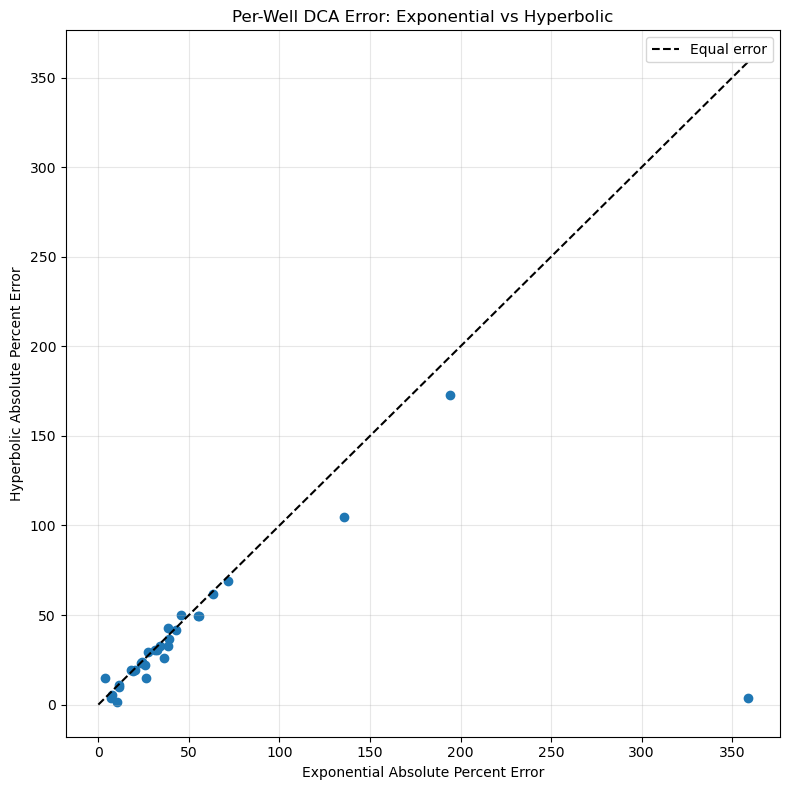

In [127]:
plt.figure(figsize=(8, 8))

plt.scatter(
    dca_per_well_comparison["exponential_absolute_percent_error"],
    dca_per_well_comparison["hyperbolic_absolute_percent_error"],
)

max_error = max(
    dca_per_well_comparison["exponential_absolute_percent_error"].max(),
    dca_per_well_comparison["hyperbolic_absolute_percent_error"].max(),
)

plt.plot(
    [0, max_error],
    [0, max_error],
    linestyle="--",
    color="black",
    label="Equal error",
)

plt.title("Per-Well DCA Error: Exponential vs Hyperbolic")
plt.xlabel("Exponential Absolute Percent Error")
plt.ylabel("Hyperbolic Absolute Percent Error")
plt.legend()
plt.grid(True, alpha=0.30)
plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "dca_exponential_vs_hyperbolic_error_scatter.png",
    dpi=150,
)

plt.show()

## Exponential vs Hyperbolic DCA Comparison Checkpoint

We compared per-well exponential and hyperbolic decline forecasts over the same forecast-check window.

Shared setup:

- Wells: 30
- Fit window: months 12-24
- Forecast-check window: months 25-33
- Target: total oil production over months 25-33

Comparison method:

- Each model was evaluated using absolute percent error by well.
- The model with lower absolute percent error was labeled as the better model for that well.
- Summary tables were saved for model-level comparison.

Outputs created:

- `dca_per_well_exponential_vs_hyperbolic_comparison.csv`
- `dca_exponential_vs_hyperbolic_model_summary.csv`
- `dca_exponential_vs_hyperbolic_win_counts.csv`
- `dca_exponential_vs_hyperbolic_error_scatter.png`

Interpretation questions:

- Did hyperbolic decline win on more wells than exponential decline?
- Did hyperbolic reduce average or median absolute percent error?
- Did the added `b` factor reduce forecast bias?
- Are improvements concentrated in only a few wells, or broadly distributed?

Project decision:

This comparison gives the first side-by-side DCA model benchmark. The next model family to evaluate is harmonic decline, which is a special case of hyperbolic decline where `b = 1`.